# **Heart disease**

In [2]:
import pandas as pd
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score , classification_report , confusion_matrix
from sklearn.model_selection import train_test_split

In [3]:
df = pd.read_csv('https://raw.githubusercontent.com/ChickenMan-1080/ML-Practice/refs/heads/main/ML-Heart/assets/heart.csv')
df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [5]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [6]:
df.isnull().sum()

,0
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


In [7]:
df['Age'].median()

54.0

# EDA

<Axes: ylabel='count'>

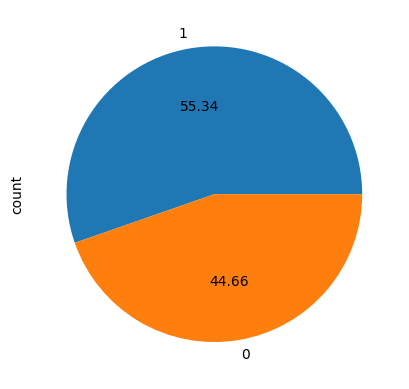

In [8]:
#target
df['HeartDisease'].value_counts().plot.pie(autopct='%.2f')

<Axes: xlabel='Age', ylabel='Count'>

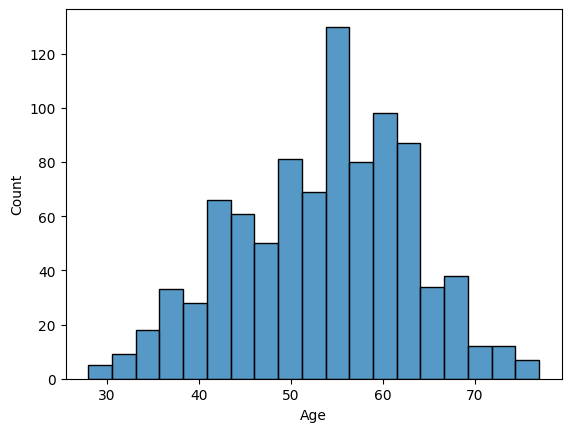

In [9]:
#Age
sns.histplot(df,x='Age')

/tmp/ipykernel_67579/2412603038.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(df,x='Sex',palette='Spectral')


<Axes: xlabel='Sex', ylabel='count'>

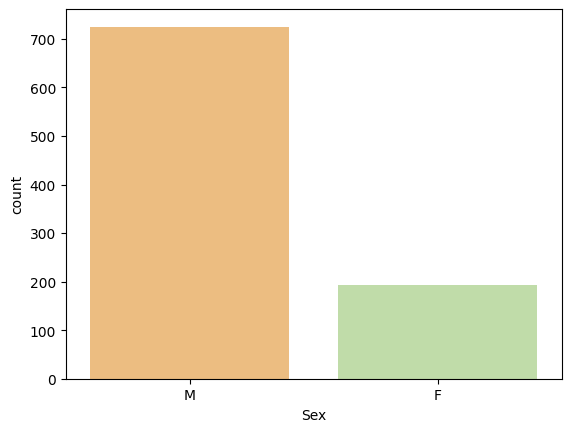

In [10]:
sns.countplot(df,x='Sex',palette='Spectral')

/tmp/ipykernel_67579/1128492245.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(df,x='ChestPainType',palette='Spectral')


<Axes: xlabel='ChestPainType', ylabel='count'>

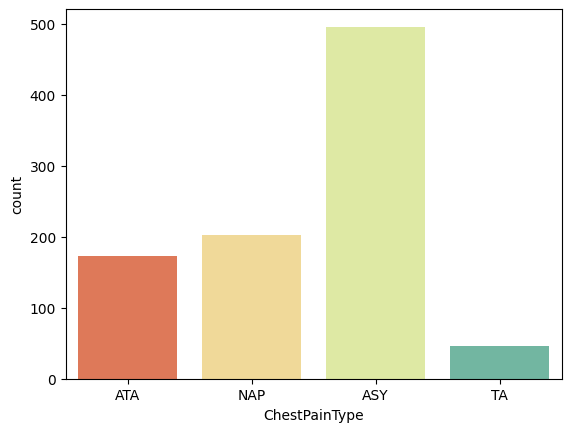

In [11]:
sns.countplot(df,x='ChestPainType',palette='Spectral')

<Axes: xlabel='RestingBP'>

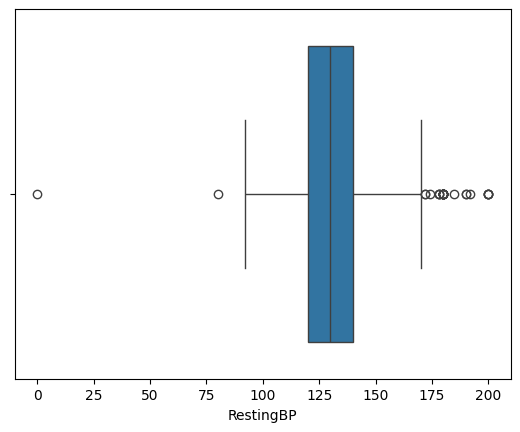

In [12]:
sns.boxplot(df,x='RestingBP')

### Clean RestingBP

<Axes: xlabel='RestingBP'>

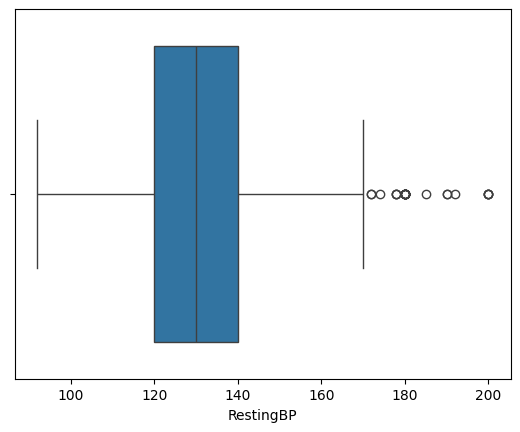

In [13]:
Q1_RestingBP = df['RestingBP'].quantile(0.25)
Q3_RestingBP = df['RestingBP'].quantile(0.75)
IQR_RestingBP = Q3_RestingBP - Q1_RestingBP

df_drop_outliers = df[df['RestingBP'] >= Q1_RestingBP - (1.5 * IQR_RestingBP)]
sns.boxplot(df_drop_outliers,x='RestingBP')

In [14]:
print(df[df['RestingBP'] > Q3_RestingBP + (1.5*IQR_RestingBP)].shape)
df_drop_outliers[df_drop_outliers['RestingBP'] > Q3_RestingBP + (1.5*IQR_RestingBP)]

(26, 12)


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
109,39,M,ATA,190,241,0,Normal,106,N,0.0,Up,0
123,58,F,ATA,180,393,0,Normal,110,Y,1.0,Flat,1
189,53,M,ASY,180,285,0,ST,120,Y,1.5,Flat,1
190,46,M,ASY,180,280,0,ST,120,N,0.0,Up,0
241,54,M,ASY,200,198,0,Normal,142,Y,2.0,Flat,1
274,45,F,ATA,180,295,0,Normal,180,N,0.0,Up,0
275,59,M,NAP,180,213,0,Normal,100,N,0.0,Up,0
278,57,F,ASY,180,347,0,ST,126,Y,0.8,Flat,0
365,64,F,ASY,200,0,0,Normal,140,Y,1.0,Flat,1
372,63,M,ASY,185,0,0,Normal,98,Y,0.0,Up,1


In [15]:
df_drop_outliers[(df_drop_outliers['RestingBP'] >= 180) & (df_drop_outliers['Cholesterol'] != 0)]['HeartDisease'].value_counts()

,count
HeartDisease,
1,9
0,6


#### Cholesterol

<Axes: xlabel='Cholesterol'>

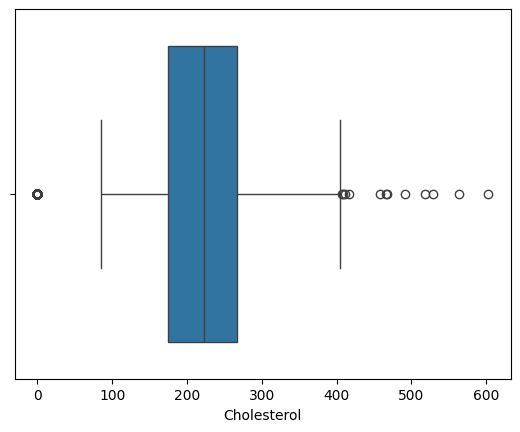

In [16]:
sns.boxplot(df_drop_outliers,x='Cholesterol')

In [17]:
df_drop_outliers = df_drop_outliers[df_drop_outliers['Cholesterol']  >= 120]
df_drop_outliers.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,740.000000,740.000000,740.000000,740.000000,740.000000,740.000000,740.000000
mean,52.841892,133.133784,245.774324,0.167568,140.335135,0.896757,0.475676
std,9.470594,17.236544,58.009743,0.373734,24.572691,1.069855,0.499746
min,28.000000,94.000000,123.000000,0.000000,69.000000,-0.100000,0.000000
25%,46.000000,120.000000,208.000000,0.000000,122.000000,0.000000,0.000000
50%,54.000000,130.000000,238.000000,0.000000,140.000000,0.500000,0.000000
75%,59.000000,140.000000,275.250000,0.000000,160.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


<Axes: xlabel='Cholesterol'>

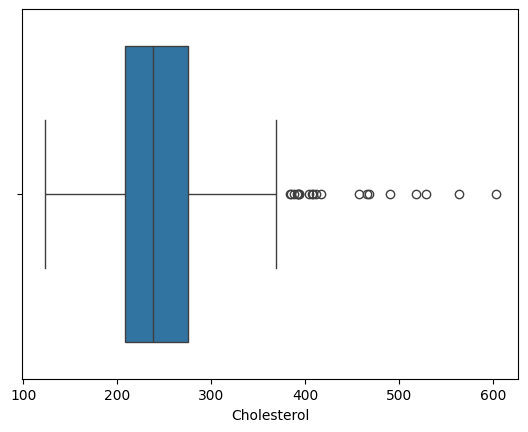

In [18]:
sns.boxplot(df_drop_outliers,x='Cholesterol')

In [19]:
Q1_Cholesterol = df_drop_outliers['Cholesterol'].quantile(0.25)
Q3_Cholesterol = df_drop_outliers['Cholesterol'].quantile(0.75)
IQR_Cholesterol = Q3_Cholesterol - Q1_Cholesterol

df_drop_outliers[df_drop_outliers['Cholesterol'] > Q3_Cholesterol + (1.5 * IQR_Cholesterol)]['HeartDisease'].value_counts()

,count
HeartDisease,
1,12
0,8


In [20]:
df_drop_outliers[(df_drop_outliers['Cholesterol'] > Q3_Cholesterol + (1.5 * IQR_Cholesterol)) & (df_drop_outliers['Cholesterol'] < 450)].describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000
mean,56.333333,148.666667,398.250000,0.250000,140.750000,1.266667,0.583333
std,8.037790,14.877276,11.087462,0.452267,18.020821,1.188072,0.514929
min,40.000000,130.000000,384.000000,0.000000,110.000000,0.000000,0.000000
25%,54.250000,140.000000,391.000000,0.000000,128.500000,0.225000,0.000000
50%,57.000000,145.000000,394.000000,0.000000,142.500000,1.100000,1.000000
75%,62.250000,152.500000,407.500000,0.250000,154.750000,2.000000,1.000000
max,67.000000,180.000000,417.000000,1.000000,170.000000,4.000000,1.000000


<Axes: xlabel='Cholesterol'>

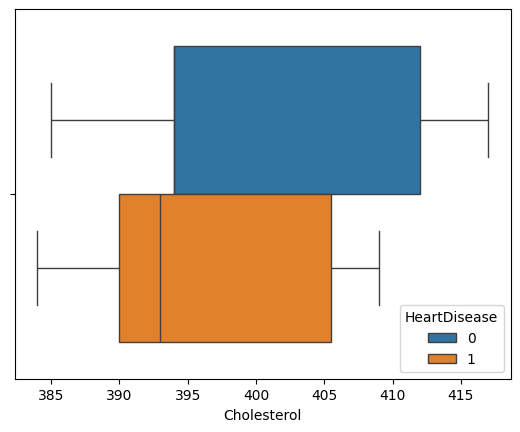

In [21]:
sns.boxplot(df_drop_outliers[(df_drop_outliers['Cholesterol'] > Q3_Cholesterol + (1.5 * IQR_Cholesterol)) & (df_drop_outliers['Cholesterol'] < 450)],x='Cholesterol',hue='HeartDisease')

In [28]:
df_drop_outliers[(df_drop_outliers['Cholesterol'] < 450) & (df_drop_outliers['HeartDisease'] == 1)].max()

,0
Age,77
Sex,M
ChestPainType,TA
RestingBP,200
Cholesterol,409
FastingBS,1
RestingECG,ST
MaxHR,195
ExerciseAngina,Y
Oldpeak,6.2


In [30]:
df_drop_outliers = df_drop_outliers[df_drop_outliers['Cholesterol'] <= 409]
df_drop_outliers.max()

,0
Age,77
Sex,M
ChestPainType,TA
RestingBP,200
Cholesterol,409
FastingBS,1
RestingECG,ST
MaxHR,202
ExerciseAngina,Y
Oldpeak,6.2
